In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset

In [3]:
df = pd.read_csv("C:/Users/Admin/Downloads/car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.shape

(301, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Check Missing Values

In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Remove Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(2)

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

Data Cleaning

In [13]:
df["Fuel_Type"] = df["Fuel_Type"].str.strip().str.title()
df["Seller_Type"] = df["Seller_Type"].str.strip().str.title()
df["Transmission"] = df["Transmission"].str.strip().str.title()

In [14]:
print(df["Fuel_Type"].unique())
print(df["Seller_Type"].unique())
print(df["Transmission"].unique())

['Petrol' 'Diesel' 'Cng']
['Dealer' 'Individual']
['Manual' 'Automatic']


Feature Engineering

Calculate Car Age

In [15]:
current_year = 2026

df["Car_Age"] = current_year - df["Year"]

In [16]:
df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [17]:
df["Brand"] = df["Car_Name"].str.split().str[0]

In [18]:
df[["Car_Name", "Brand"]].head(10)

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift
5,vitara brezza,vitara
6,ciaz,ciaz
7,s cross,s
8,ciaz,ciaz
9,ciaz,ciaz


In [19]:
df = df.drop("Car_Name", axis=1)

Exploratory Data Analysis

Selling Price Distribution

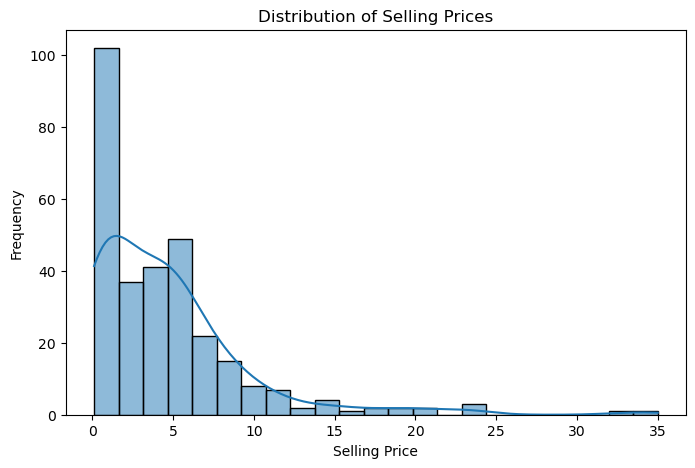

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

Price vs Fuel Type

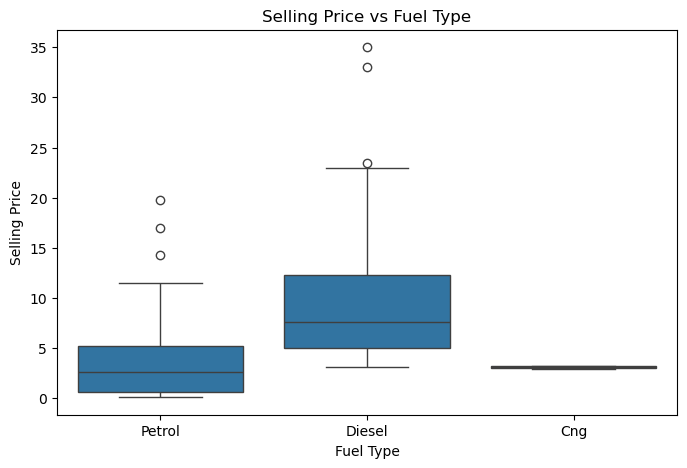

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Fuel_Type",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price vs Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

Price vs Car Age

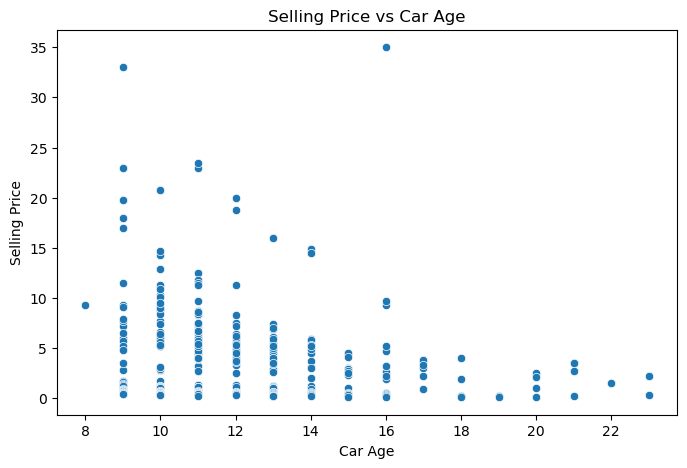

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Car_Age",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

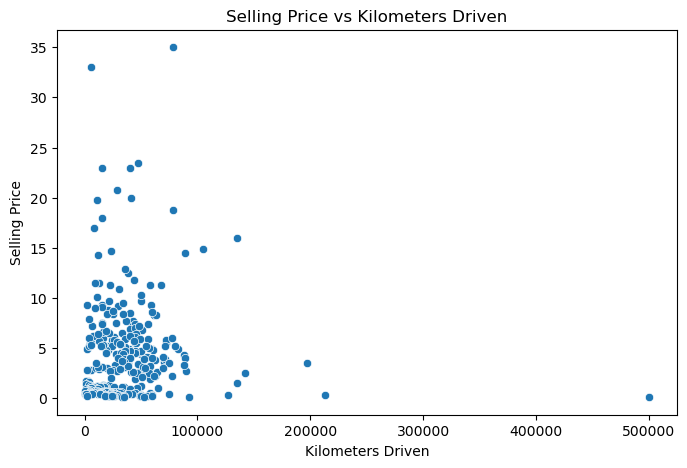

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Kms_Driven",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()

Correlation Heatmap

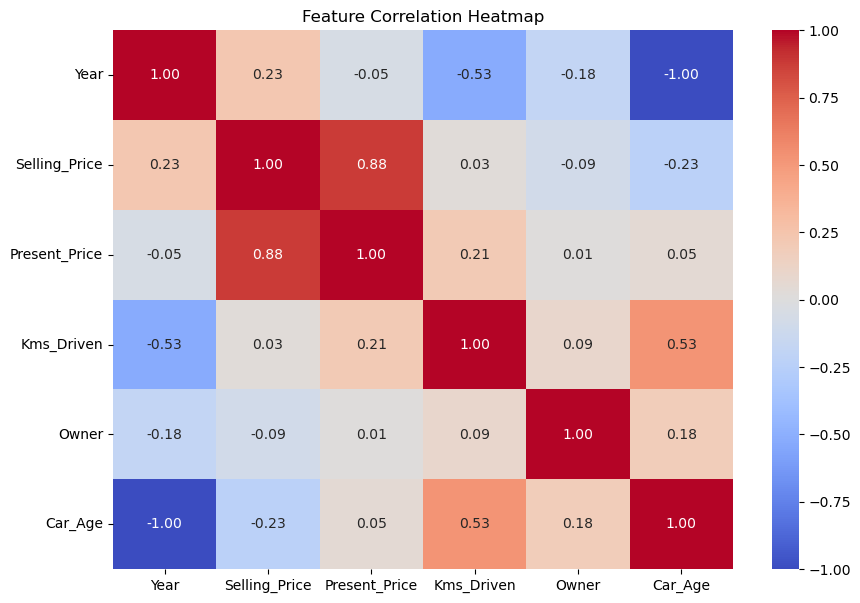

In [25]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

Encode Categorical Variables

In [26]:
categorical_features = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Brand"
]

In [53]:
numerical_features = [
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age"
]

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

Define X and y

In [55]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Model 1 – Linear Regression

In [57]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [58]:
linear_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
y_pred_linear = linear_model.predict(X_test)

In [60]:
y_pred_linear

array([ 8.14948467,  7.8808404 ,  2.09423789,  6.78509759, 10.01715964,
        4.89990436,  8.02703594,  2.07800257,  8.57789821, -0.63310582,
       10.95595938, -1.50945675, -0.18010749,  1.46332421,  4.38221561,
        4.48220254,  1.47187254,  1.69308261, 21.85750241,  0.54967966,
        0.62758914,  2.56822971,  5.71763156,  0.16416746,  5.72595063,
        8.36966818,  8.50896775,  1.46742219,  5.2885007 ,  5.34831855,
        4.27864255,  5.58856016,  5.73607886,  2.77219605,  2.44880012,
        6.53622934,  1.57779394, -8.37921317,  1.57121696,  9.13263089,
        6.74254495, 12.6608943 ,  1.84448086,  2.64052986,  0.68407717,
       -2.85948699,  9.1880777 ,  3.84558409,  5.12178767, -0.18189143,
        1.26584874,  0.76207107,  8.84468003,  9.89495253,  7.75816037,
        4.95613998,  3.64907734,  3.43371264,  9.57728582,  8.81582675])

Model 2 – Random Forest Regressor

In [61]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [62]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
y_pred_rf = rf_model.predict(X_test)

In [64]:
y_pred_rf

array([ 9.48595,  7.99085,  0.43745,  7.2735 , 18.0125 ,  5.31275,
        6.82   ,  1.17575,  7.8688 ,  0.3117 , 15.3907 ,  0.2361 ,
        0.2524 ,  0.4466 ,  4.53275,  5.0503 ,  0.6064 ,  1.207  ,
       21.70025,  0.55325,  0.5632 ,  2.49275,  6.235  ,  2.289  ,
        6.1321 ,  8.81685,  8.35375,  1.16425,  4.79205,  5.34335,
        3.37575,  4.581  ,  6.0901 ,  2.71825,  3.02825,  6.77475,
        1.15575,  0.1678 ,  1.193  , 17.92325,  6.80925,  9.8969 ,
        0.90035,  3.5876 ,  0.562  ,  0.237  , 10.172  ,  4.57075,
        3.987  ,  0.2022 ,  0.5905 ,  0.32245, 18.5337 , 10.41175,
        7.67785,  6.61175,  3.27025,  3.6965 , 10.44015,  7.33975])

Model Evaluation

In [65]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)
    print("-" * 40)

In [66]:
evaluate_model(
    y_test,
    y_pred_linear,
    "Linear Regression"
)

evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)

Linear Regression
MAE : 1.3573778436365902
RMSE: 2.4186408182259833
R²  : 0.7730274360633704
----------------------------------------
Random Forest
MAE : 1.4837349999999998
RMSE: 3.679103601864184
R²  : 0.4748121833960479
----------------------------------------


In [67]:
results = []

models = {
    "Linear Regression": y_pred_linear,
    "Random Forest": y_pred_rf
}

for name, predictions in models.items():

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.357378,2.418641,0.773027
1,Random Forest,1.483735,3.679104,0.474812


Feature Importance

In [68]:
rf = rf_model.named_steps["model"]

encoder = rf_model.named_steps["preprocessor"].named_transformers_["cat"]

encoded_features = encoder.get_feature_names_out(
    categorical_features
)

feature_names = list(encoded_features) + numerical_features

In [75]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

ValueError: All arrays must be of the same length

In [70]:
feature_importance.head(15)

,Feature,Importance
47,Present_Price,0.886749
50,Car_Age,0.043417
46,Year,0.030638
38,Brand_land,0.011819
48,Kms_Driven,0.010160
6,Transmission_Manual,0.002904
24,Brand_corolla,0.002809
5,Transmission_Automatic,0.002656
4,Seller_Type_Individual,0.001672
36,Brand_innova,0.001636


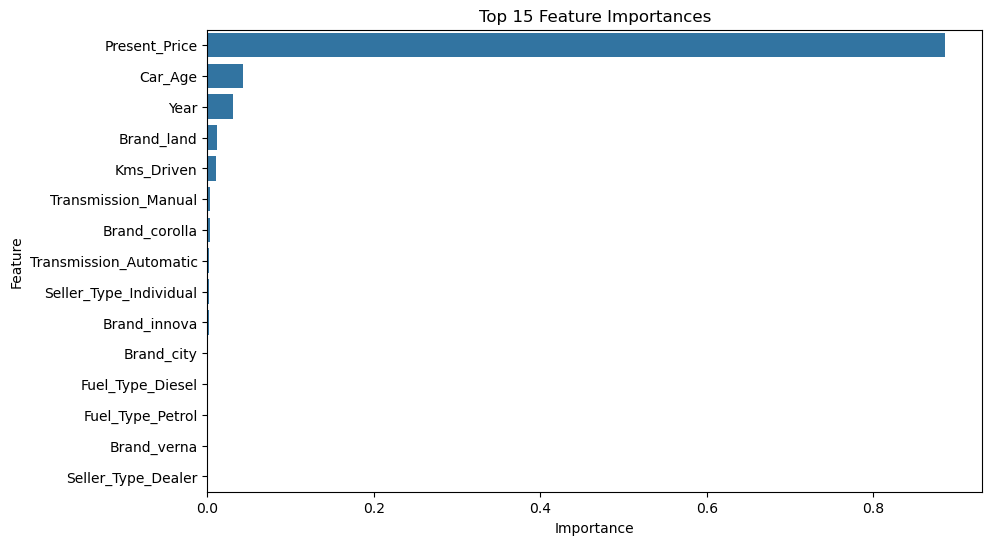

In [71]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Actual vs Predicted Price

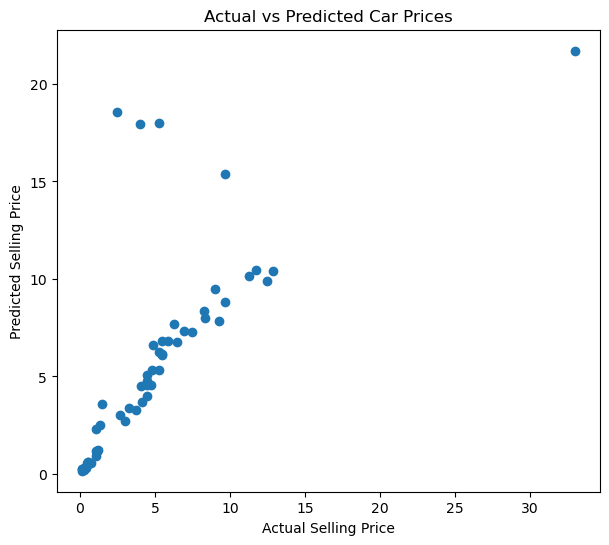

In [72]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()

Test a Sample Car

In [73]:
sample_car = pd.DataFrame({
    "Year": [2018],
    "Present_Price": [8.5],
    "Kms_Driven": [40000],
    "Fuel_Type": ["Petrol"],
    "Seller_Type": ["Dealer"],
    "Transmission": ["Manual"],
    "Owner": [0],
    "Car_Age": [8],
    "Brand": ["Honda"]
})

In [74]:
predicted_price = rf_model.predict(sample_car)

print(
    "Predicted Selling Price:",
    predicted_price[0]
)

Predicted Selling Price: 7.184800000000007


Final Conclusion



In this project, a machine learning based car price prediction system
was developed using the Vehicle Dataset from CarDekho.

The dataset was cleaned by handling missing values, removing duplicate
records and standardizing categorical values. Feature engineering was
performed by calculating car age from the manufacturing year and
extracting the car brand from the car name.

Exploratory Data Analysis was conducted to understand the distribution
of selling prices and the relationship between car prices and different
features.

Multiple regression models including Linear Regression, Random Forest
Regressor and Gradient Boosting Regressor were trained and evaluated
using MAE, RMSE and R² score.

The models were compared based on their evaluation metrics, and feature
importance was analyzed for the selected tree-based model.

This project demonstrates how machine learning can be used to estimate
used-car prices based on historical vehicle characteristics.